In [7]:
import pandas as pd
print(pd.__version__)
df= pd.read_csv("../data/titanic.csv")

print(df.shape)
df.head()

2.3.2
(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
df.describe(include='number')

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df.sample(5,random_state=0)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
495,496,0,3,"Yousseff, Mr. Gerious",male,NaN,0,0,2627,14.4583,NaN,C
648,649,0,3,"Willey, Mr. Edward",male,NaN,0,0,S.O./P.P. 751,7.5500,NaN,S
278,279,0,3,"Rice, Master. Eric",male,7.0,4,1,382652,29.1250,NaN,Q
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
255,256,1,3,"Touma, Mrs. Darwis (Hanne Youssef Razi)",female,29.0,0,2,2650,15.2458,NaN,C


In [11]:
df.isna().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [12]:
df=df.drop(columns="Cabin")
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

C:\Users\art\AppData\Local\Temp\ipykernel_6728\1435030693.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


In [13]:
df["Age"] = df.groupby(["Sex", "Pclass"])["Age"].transform(
    lambda x: x.fillna(x.median())
)
#We are grouping people because age is strongly linked to the sex and poor/rich

In [14]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [15]:
df["Survived"].value_counts(normalize=True).round(3)

Survived
0    0.616
1    0.384
Name: proportion, dtype: float64

In [ ]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [16]:
df.groupby(["Sex", "Pclass"])["Survived"].mean().round(3)

Sex     Pclass
female  1         0.968
        2         0.921
        3         0.500
male    1         0.369
        2         0.157
        3         0.135
Name: Survived, dtype: float64

In [ ]:
df.groupby([pd.cut(df["Age"], [0,12,18,60,80]),"Sex", "Pclass"])["Survived"].mean().round(3)

C:\Users\art\AppData\Local\Temp\ipykernel_6728\2119926095.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([pd.cut(df["Age"], [0,12,18,60,80]),"Sex", "Pclass"])["Survived"].mean().round(3)


Age       Sex     Pclass
(0, 12]   female  1         0.000
                  2         1.000
                  3         0.478
          male    1         1.000
                  2         1.000
                  3         0.360
(12, 18]  female  1         1.000
                  2         1.000
                  3         0.550
          male    1         0.500
                  2         0.000
                  3         0.077
(18, 60]  female  1         0.975
                  2         0.903
                  3         0.490
          male    1         0.381
                  2         0.078
                  3         0.123
(60, 80]  female  1         1.000
                  2           NaN
                  3         1.000
          male    1         0.083
                  2         0.333
                  3         0.000
Name: Survived, dtype: float64

In [20]:
df[(df["Age"] > 60) & (df["Age"] <= 80) & (df["Sex"] == "female") & (df["Pclass"] == 2)]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


In [32]:
df.groupby("Embarked")["Survived"].mean().round(3)

Embarked
C    0.554
Q    0.390
S    0.339
Name: Survived, dtype: float64

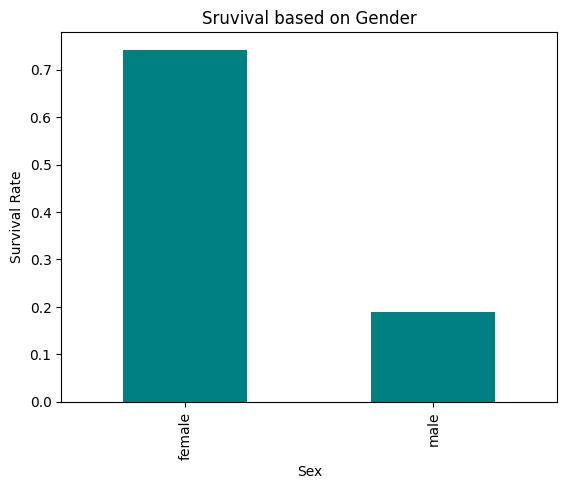

In [26]:
import matplotlib.pyplot as plt    
df.groupby('Sex')['Survived'].mean().plot(kind='bar',color='teal')
plt.title("Sruvival based on Gender")
plt.ylabel("Survival Rate")
plt.show()

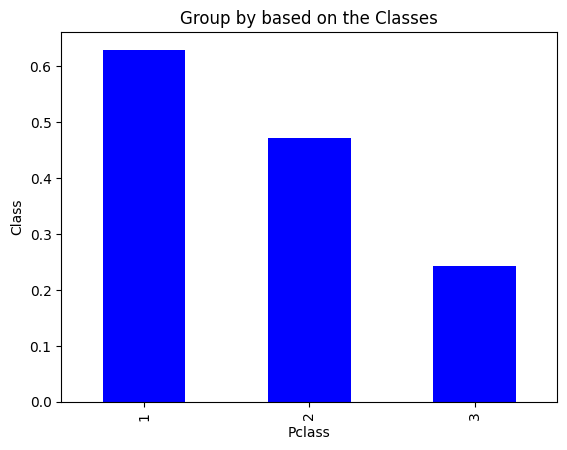

In [27]:
df.groupby('Pclass')['Survived'].mean().plot(kind='bar',color='blue')
plt.title('Group by based on the Classes')
plt.ylabel('Class')
plt.show()

C:\Users\art\AppData\Local\Temp\ipykernel_6728\3894270295.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([pd.cut(df['Age'],[0,12,18,60,80]),"Sex"])['Survived'].mean().plot(kind='bar', color='black')


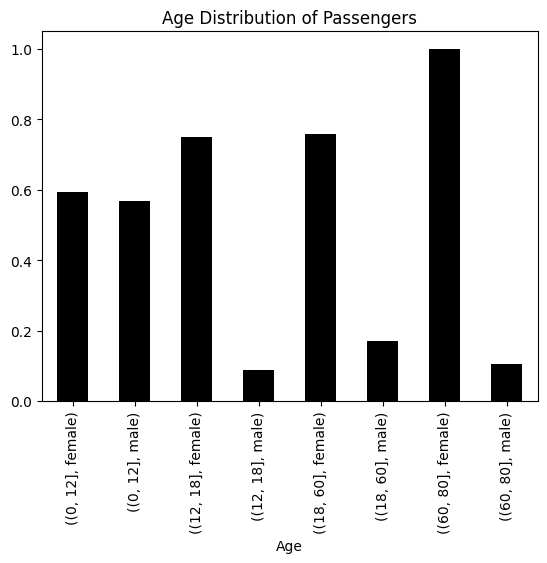

In [37]:
df.groupby([pd.cut(df['Age'],[0,12,18,60,80]),"Sex"])['Survived'].mean().plot(kind='bar', color='black')

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.show()


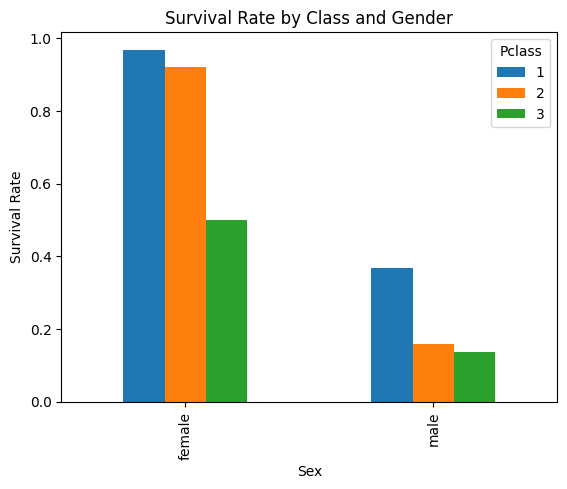

In [39]:
pd.crosstab(df["Sex"],df["Pclass"],  values=df["Survived"], aggfunc="mean").plot(kind="bar")
plt.title("Survival Rate by Class and Gender")
plt.ylabel("Survival Rate")
plt.show()
